In [4]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,mean_absolute_error
from sklearn.metrics import accuracy_score,r2_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:

df = pd.read_csv(r"C:\Users\dines\OneDrive\Desktop\Battery Health & Remaining Life\battery_rul_dataset.csv ", engine="python", encoding="latin1", on_bad_lines="skip")


In [6]:
print(df.isnull().sum())
print(df.shape)
print(df.describe())
print(df.info())
print(df.columns)


Cycle_Index                  0
Discharge Time (s)           0
Decrement 3.6-3.4V (s)       0
Max. Voltage Dischar. (V)    0
Min. Voltage Charg. (V)      0
Time at 4.15V (s)            0
Time constant current (s)    0
Charging time (s)            0
RUL                          0
dtype: int64
(15064, 9)
        Cycle_Index  Discharge Time (s)  Decrement 3.6-3.4V (s)  \
count  15064.000000        15064.000000            15064.000000   
mean     556.155005         4581.273960             1239.784672   
std      322.378480        33144.012077            15039.589269   
min        1.000000            8.690000          -397645.908000   
25%      271.000000         1169.310000              319.600000   
50%      560.000000         1557.250000              439.239471   
75%      833.000000         1908.000000              600.000000   
max     1134.000000       958320.370000           406703.768000   

       Max. Voltage Dischar. (V)  Min. Voltage Charg. (V)  Time at 4.15V (s)  \
count        

In [7]:
X=df.drop(columns=['RUL'])
y=df['RUL']

In [8]:
number_cols=X.select_dtypes(include=['int64','float64']).columns
categorical_col=X.select_dtypes(include=['object','category']).columns


In [9]:
numerical_transform=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='median')),
    ('scalar',StandardScaler())
    ])
categorical_transform=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('onehot',OneHotEncoder(handle_unknown='ignore'))
])
preprocessing=ColumnTransformer(transformers=[
    ('num',numerical_transform,number_cols),
    ('cat',categorical_transform,categorical_col)
])

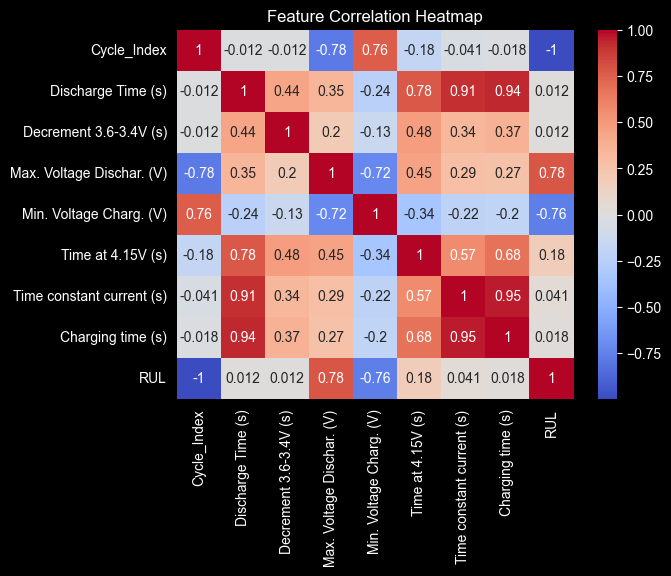

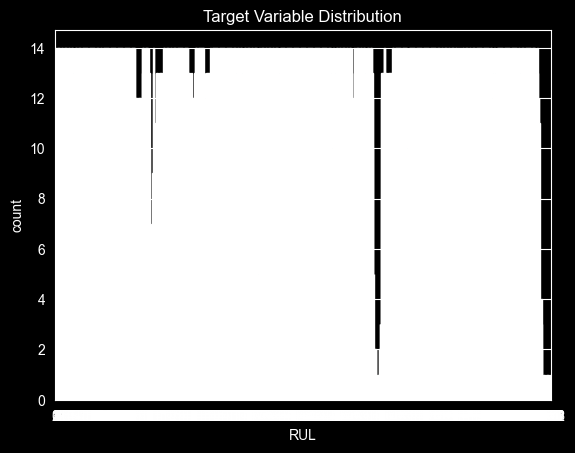

In [10]:
plt.Figure(figsize=(10,6))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()
sns.countplot(x=y)
plt.title('Target Variable Distribution')
plt.show()

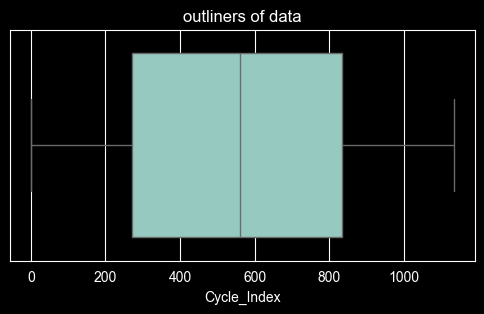

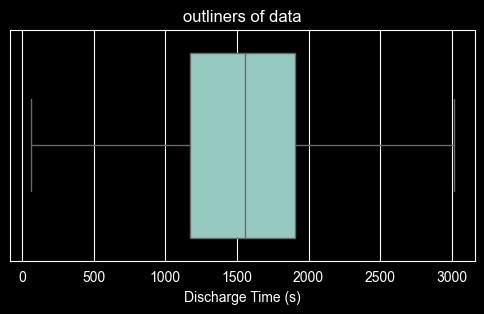

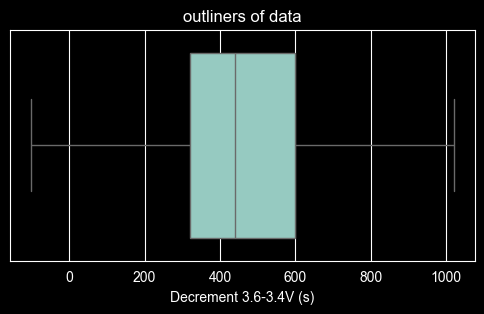

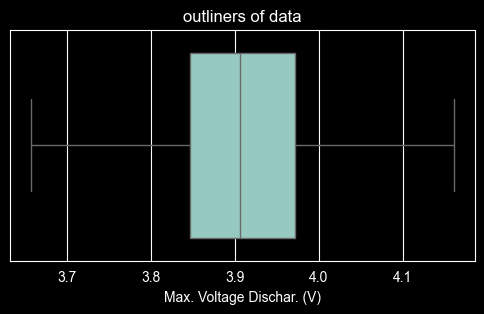

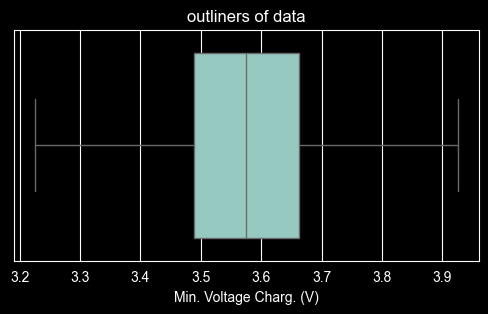

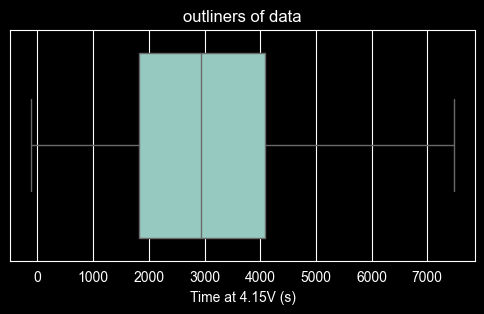

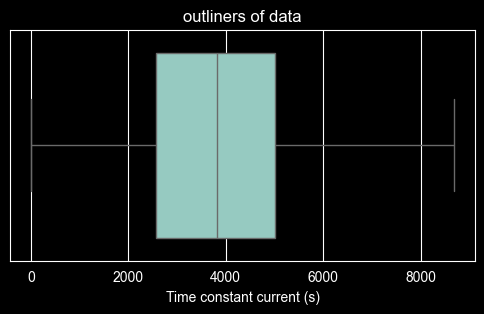

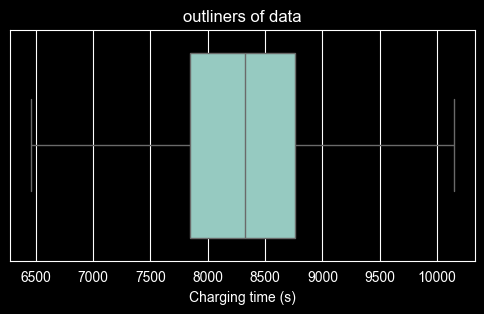

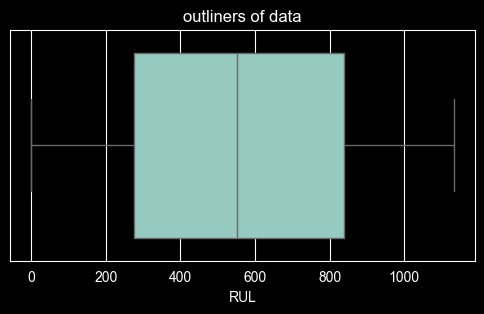

In [11]:
for i in df.select_dtypes(include='number').columns:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[i])
    plt.title('outliners of data')
    # plt.show()
    plt.close()
for k in df.select_dtypes(include='number').columns:
    q1=df[k].quantile(0.25)
    q3=df[k].quantile(0.75)
    IQR=q3-q1
    lower_limit=q1-1.5*IQR
    upper_limit=q3+1.5*IQR
    df[k]=np.where(df[k]<lower_limit,lower_limit,
                   np.where(df[k]>upper_limit,upper_limit,df[k]))
for i in df.select_dtypes(include='number').columns:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[i])
    plt.title('outliners of data')
    plt.show()


In [12]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [13]:
models={
    'randomforest':RandomForestRegressor(),
    'Xgb_model':XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0,
    reg_lambda=1,
    reg_alpha=0,
    objective='reg:squarederror',
    random_state=42
    ),   
    'decision':DecisionTreeRegressor(
        criterion='friedman_mse',
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42
    )
}
result={}
for name ,model in models.items():
    model.fit(X_train,y_train)
    y_predict=model.predict(X_test)
    score=r2_score(y_predict,y_test)
    result[name]=score
for name,score in result.items():
    print(f"{name} : {score:.4f}")

randomforest : 0.9999
Xgb_model : 0.9996
decision : 0.9770


In [14]:
mse=mean_squared_error(y_predict,y_test)
rmse=np.sqrt(mean_squared_error(y_predict,y_test))
mae=mean_absolute_error(y_predict,y_test)
print(mse,rmse,mae)

2313.312748815686 48.096909971594705 34.09335565369107


                                  0
Cycle_Index                0.768097
Discharge Time (s)         0.028765
Decrement 3.6-3.4V (s)     0.001041
Max. Voltage Dischar. (V)  0.005113
Min. Voltage Charg. (V)    0.000478
Time at 4.15V (s)          0.002630
Time constant current (s)  0.192052
Charging time (s)          0.001824


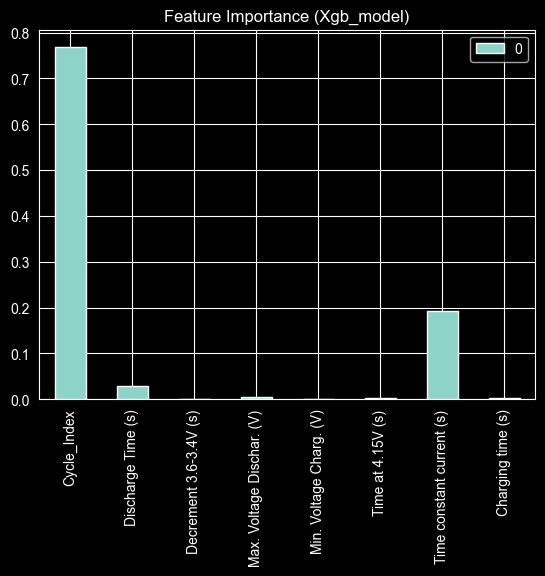

In [15]:
gradient = models['Xgb_model']
importance=gradient.feature_importances_
fearture=pd.DataFrame(data=model.feature_importances_,index=X.columns)
print(fearture)
fearture.plot(kind='bar')
plt.title('Feature Importance (Xgb_model)')
plt.show()


In [16]:
import pickle
best_model=models['Xgb_model']
pickle.dump(best_model,open('model.pkl','wb'))

In [18]:
import joblib
import os

os.makedirs('models', exist_ok=True)

joblib.dump(models['randomforest'], '../predictor/randomforest.pkl')
joblib.dump(models['Xgb_model'], '../predictor/xgboost.pkl')   # rename for consistency
joblib.dump(models['decision'], '../predictor/decision.pkl')

print("Models saved successfully!")

Models saved successfully!
